In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install node2vec tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 60.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requ

In [ ]:
 !pip uninstall -y jax numpy
 !pip cache purge

Found existing installation: jax 0.5.3
Uninstalling jax-0.5.3:
  Successfully uninstalled jax-0.5.3
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Files removed: 24


In [ ]:
 !pip install numpy==1.23.5
 !pip install --upgrade jax jaxlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 117.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.11.21 requires jax>=0.5.0, which is not installed.
optax 0.2.5 requires jax>=0.4.27, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
flax 0.10.6 requires jax>=0.5.1, which is not installed.
chex 0.1.90 requires jax>=0.4.27, which is not installed.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
treescope 0.1.10 requires numpy>=1.25.2, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
pymc 5.25.1 requires numpy>=1.25.0, but you have numpy 1.23.5 

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 377, in run
^C


In [ ]:
import pandas as pd
from tqdm import tqdm
import json
import os
import random
import math
import pickle
import numpy as np
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, confusion_matrix
from collections import deque

import networkx as nx
import warnings
import keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import activations, initializers, constraints, regularizers
from tensorflow.keras.layers import Input, Layer, Lambda, Dropout, Reshape, Dense, Embedding, LeakyReLU, Maximum
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import layers, optimizers, losses, metrics, Model
import matplotlib.pyplot as plt
import seaborn as sns

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass


In [ ]:
dataFrame = pd.read_csv("/content/drive/MyDrive/Journal/citation_sentiment_corpus.txt", sep = "	", header = None)
dataFrame.columns = ["Source_PaperID", "Target_PaperID", "Sentiment", "Citation_text"]
dataFrame.Sentiment = dataFrame.Sentiment.replace({"o": 1,"p": 2,"n": 0})

/tmp/ipython-input-2858447318.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataFrame.Sentiment = dataFrame.Sentiment.replace({"o": 1,"p": 2,"n": 0})


In [ ]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8736 entries, 0 to 8735
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Source_PaperID  8736 non-null   object
 1   Target_PaperID  8736 non-null   object
 2   Sentiment       8736 non-null   int64 
 3   Citation_text   8736 non-null   object
dtypes: int64(1), object(3)
memory usage: 273.1+ KB


In [ ]:
Source = dataFrame['Source_PaperID']
Target = dataFrame['Target_PaperID']
Sentiment = dataFrame['Sentiment']

In [ ]:
import math

def directed_preferential_attachment(graph, edges):
    """
    Preferential Attachment for directed graphs:
    PA(u, v) = out_degree(u) * in_degree(v)
    """
    scores = []
    for u, v in edges:
        score = graph.out_degree(u) * graph.in_degree(v)
        scores.append((u, v, score))
    return scores


def directed_resource_allocation_index(graph, edges):
    """
    Resource Allocation Index for directed graphs:
    Use common nodes that are successors of u and predecessors of v.
    RA(u, v) = sum over w ∈ Γ_out(u) ∩ Γ_in(v) of 1 / degree(w)
    """
    scores = []
    for u, v in edges:
        common_neighbors = set(graph.successors(u)).intersection(set(graph.predecessors(v)))
        score = sum(1 / graph.degree(w) for w in common_neighbors if graph.degree(w) > 0)
        scores.append((u, v, score))
    return scores


def directed_jaccard_coefficient(graph, edges):
    """
    Jaccard Coefficient for directed graphs:
    JC(u, v) = |Γ_out(u) ∩ Γ_in(v)| / |Γ_out(u) ∪ Γ_in(v)|
    """
    scores = []
    for u, v in edges:
        succ_u = set(graph.successors(u))     # out-neighbors of u
        pred_v = set(graph.predecessors(v))   # in-neighbors of v
        intersection = succ_u & pred_v
        union = succ_u | pred_v
        score = len(intersection) / len(union) if union else 0
        scores.append((u, v, score))
    return scores


def directed_adamic_adar_index(graph, edges):
    """
    Adamic-Adar Index for directed graphs:
    AA(u, v) = sum over w ∈ Γ_out(u) ∩ Γ_in(v) of 1 / log(degree(w))
    """
    scores = []
    for u, v in edges:
        succ_u = set(graph.successors(u))     # out-neighbors of u
        pred_v = set(graph.predecessors(v))   # in-neighbors of v
        common_neighbors = succ_u & pred_v
        score = sum(1 / math.log(graph.degree(w)) for w in common_neighbors if graph.degree(w) > 1)
        scores.append((u, v, score))
    return scores


In [ ]:
import networkx as nx
import pandas as pd


edges = pd.DataFrame({
    "source": Source,
    "target": Target,
    "weight": [1] * len(Source)  # or use real weights if available
})

G = nx.from_pandas_edgelist(
    edges,
    source='source',
    target='target',
    edge_attr=True,
    create_using=nx.DiGraph()
)


In [ ]:
leaderboard = {node: G.degree(node) for node in G.nodes()}

s = pd.Series(leaderboard, name="Citations")
citation_counts = s.to_frame().sort_values("Citations", ascending=False)

citation_value_counts = citation_counts.value_counts()

print("Citation Counts:")
print(citation_counts.head())  # Top-ranked nodes by citations
print("\nValue Counts of Citations:")
print(citation_value_counts)


Citation Counts:
          Citations
J93-2004        436
J93-2003        368
P02-1040        305
P03-1021        281
N03-1017        240

Value Counts of Citations:
Citations
1            1755
2             684
3             283
4             129
5              77
6              26
7              14
8              13
9              11
10              7
11              5
15              4
17              4
20              4
14              4
22              3
13              2
18              2
71              2
27              2
30              2
12              2
151             1
101             1
109             1
117             1
121             1
125             1
138             1
172             1
152             1
368             1
182             1
212             1
240             1
281             1
305             1
95              1
31              1
67              1
29              1
16              1
19              1
23              1
24              1
25             

In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  3069
Number of Edges:  5042


In [ ]:
#!pip install node2vec

In [ ]:
df=dataFrame
import pandas as pd
import numpy as np
from node2vec import Node2Vec
import tensorflow_hub as hub
import tensorflow as tf


In [ ]:
leaderboard = {}
for x in G.nodes:
 leaderboard[x] = len(G[x])
s = pd.Series(leaderboard, name='Citations')
citation_counts = s.to_frame().sort_values('Citations', ascending=False)
citation_counts.value_counts()

,count
Citations,
1,1785
2,703
3,295
4,121
0,77
5,59
6,19
7,7
8,3


In [ ]:
citation_counts = citation_counts.reset_index(level=0)
citation_counts.columns = ['Node', 'Citations']
citation_counts.head()

,Node,Citations
0,W08-0306,8
1,N09-1058,8
2,D07-1070,8
3,N09-1049,7
4,P08-1068,7


In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  3069
Number of Edges:  5042


In [ ]:
zero_list = []
for i,j in zip(citation_counts['Node'], citation_counts['Citations']):
    if(j == 0):

        zero_list.append(i)
G.remove_nodes_from(zero_list)

In [ ]:

#NODE-LEVEL FEATURES

# In-degree, Out-degree, Total Degree Centrality
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Betweenness, Closeness, Eigenvector Centrality
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

# Combine Node Features into a DataFrame
node_features = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_degrees[node] for node in G.nodes()],
    "out_degree": [out_degrees[node] for node in G.nodes()],
    "total_degree": [total_degrees[node] for node in G.nodes()],
    "betweenness": [betweenness[node] for node in G.nodes()],
    "closeness": [closeness[node] for node in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[node] for node in G.nodes()],
})


# EDGE-LEVEL FEATURES
# Preferential Attachment
pref_attach = directed_preferential_attachment(G, G.edges())

# Resource Allocation Index
resource_allocation_scores = directed_resource_allocation_index(G, G.edges())

# Jaccard Coefficient
jaccard_scores = directed_jaccard_coefficient(G, G.edges())

# Adamic-Adar Index
adamic_adar_scores = directed_adamic_adar_index(G, G.edges())

# Combine Edge Features into a DataFrame
edge_features = pd.DataFrame({
    "source": [u for u, v, _ in pref_attach],
    "target": [v for u, v, _ in pref_attach],
    "preferential_attachment": [score for _, _, score in pref_attach],
    "resource_allocation": [score for _, _, score in resource_allocation_scores],
    "jaccard": [score for _, _, score in jaccard_scores],
    "adamic_adar": [score for _, _, score in adamic_adar_scores],
})



In [ ]:
print(edge_features.describe())

       preferential_attachment  resource_allocation      jaccard  adamic_adar
count              1589.000000          1589.000000  1589.000000  1589.000000
mean                141.224670             0.011998     0.002853     0.053190
std                 177.346121             0.050893     0.015371     0.179574
min                   1.000000             0.000000     0.000000     0.000000
25%                  20.000000             0.000000     0.000000     0.000000
50%                  68.000000             0.000000     0.000000     0.000000
75%                 169.000000             0.000000     0.000000     0.000000
max                1185.000000             0.666667     0.250000     1.820478


In [ ]:
path_lengths = []
for u, v in G.edges():
    try:
        path_length = nx.shortest_path_length(G, u, v)
    except nx.NetworkXNoPath:
        path_length = -1
    path_lengths.append(path_length)

edge_features["shortest_path_length"] = path_lengths


In [ ]:
node_features.shape , edge_features.shape

((2992, 7), (1589, 7))

In [ ]:
node_features.columns, edge_features.columns

(Index(['node', 'in_degree', 'out_degree', 'total_degree', 'betweenness',
        'closeness', 'eigenvector_centrality'],
       dtype='object'),
 Index(['source', 'target', 'preferential_attachment', 'resource_allocation',
        'jaccard', 'adamic_adar', 'shortest_path_length'],
       dtype='object'))

In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  2992
Number of Edges:  1589


In [ ]:
node2vec = Node2Vec(G, dimensions=128, walk_length=80, num_walks=10, workers=4)
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)

node2vec_embeddings = pd.DataFrame(
    [node2vec_model.wv[str(node)] for node in G.nodes()],
    index=[str(node) for node in G.nodes()],
    columns=[f"node2vec_dim_{i}" for i in range(128)]
)


Computing transition probabilities:   0%|          | 0/2992 [00:00<?, ?it/s]

In [ ]:
node2vec_embeddings.head()

,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,node2vec_dim_9,...,node2vec_dim_118,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127
A00-1043,0.002050,-0.004393,0.005529,-0.002597,0.004133,-0.002673,-0.007131,-0.001658,0.002178,-0.006705,...,-0.002351,-0.001262,0.004511,0.007227,-0.005054,-0.003262,0.006311,-0.005474,0.006385,0.002572
H05-1033,0.004189,0.005174,0.002765,0.005483,0.000675,0.001141,-0.005080,-0.005770,-0.002393,0.000846,...,0.003380,0.003035,0.006520,-0.003913,0.005658,0.000966,-0.003591,0.004098,0.002725,0.005993
I05-2009,0.005711,0.001282,-0.007578,-0.007080,-0.001135,0.003878,-0.003255,0.004952,0.000317,0.004006,...,-0.005752,0.004072,-0.002948,-0.000569,-0.000425,0.004715,0.003302,-0.007487,-0.007750,0.005221
I08-1016,-0.004554,-0.003457,-0.003612,-0.002596,-0.005901,-0.004561,0.007085,0.002228,-0.007349,-0.004456,...,-0.007427,-0.007713,0.007275,0.004168,-0.004128,-0.003276,-0.006258,0.003156,0.003845,-0.006181
I08-2101,-0.001297,0.005044,-0.002241,-0.001494,0.001104,-0.007267,0.001280,-0.001646,-0.001429,-0.007651,...,0.005237,-0.004107,-0.004282,-0.000784,-0.007396,-0.001872,0.001471,-0.006106,0.003769,-0.003328


In [ ]:
# Ensure Node2Vec embeddings cover all nodes in the original DataFrame
all_nodes = df["Source_PaperID"].unique()
missing_nodes = set(all_nodes) - set(node2vec_embeddings.index)
for node in missing_nodes:
    node2vec_embeddings.loc[node] = np.zeros(128)

In [ ]:
# Reindex to ensure the order matches `all_nodes`
node2vec_embeddings = node2vec_embeddings.reindex(all_nodes)

In [ ]:
node2vec_embeddings.shape

(2992, 128)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import tensorflow_hub as hub
import tensorflow as tf

node2vec_embeddings.index.name = "Source_PaperID"

In [ ]:
citation_texts = df[df["Source_PaperID"].isin(node2vec_embeddings.index)]
citation_texts.shape

(8736, 4)

In [ ]:
unique_citation_texts = citation_texts.groupby("Source_PaperID").first().reset_index()

In [ ]:
unique_citation_texts.shape

(2992, 4)

In [ ]:

combined_embeddings = node2vec_embeddings

sentiment_dict = df.set_index("Source_PaperID")["Sentiment"].to_dict()
combined_embeddings["sentiment"] = combined_embeddings.index.map(sentiment_dict)

final_df = combined_embeddings.reset_index()

print(final_df.head())
print("\nShape of the final DataFrame:", final_df.shape)


  Source_PaperID  node2vec_dim_0  node2vec_dim_1  node2vec_dim_2  \
0       A00-1043        0.002050       -0.004393        0.005529   
1       H05-1033        0.004189        0.005174        0.002765   
2       I05-2009        0.005711        0.001282       -0.007578   
3       I08-1016       -0.004554       -0.003457       -0.003612   
4       I08-2101       -0.001297        0.005044       -0.002241   

   node2vec_dim_3  node2vec_dim_4  node2vec_dim_5  node2vec_dim_6  \
0       -0.002597        0.004133       -0.002673       -0.007131   
1        0.005483        0.000675        0.001141       -0.005080   
2       -0.007080       -0.001135        0.003878       -0.003255   
3       -0.002596       -0.005901       -0.004561        0.007085   
4       -0.001494        0.001104       -0.007267        0.001280   

   node2vec_dim_7  node2vec_dim_8  ...  node2vec_dim_119  node2vec_dim_120  \
0       -0.001658        0.002178  ...         -0.001262          0.004511   
1       -0.005770   

In [ ]:
final_df.head()

,Source_PaperID,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127,sentiment
0,A00-1043,0.002050,-0.004393,0.005529,-0.002597,0.004133,-0.002673,-0.007131,-0.001658,0.002178,...,-0.001262,0.004511,0.007227,-0.005054,-0.003262,0.006311,-0.005474,0.006385,0.002572,1
1,H05-1033,0.004189,0.005174,0.002765,0.005483,0.000675,0.001141,-0.005080,-0.005770,-0.002393,...,0.003035,0.006520,-0.003913,0.005658,0.000966,-0.003591,0.004098,0.002725,0.005993,1
2,I05-2009,0.005711,0.001282,-0.007578,-0.007080,-0.001135,0.003878,-0.003255,0.004952,0.000317,...,0.004072,-0.002948,-0.000569,-0.000425,0.004715,0.003302,-0.007487,-0.007750,0.005221,1
3,I08-1016,-0.004554,-0.003457,-0.003612,-0.002596,-0.005901,-0.004561,0.007085,0.002228,-0.007349,...,-0.007713,0.007275,0.004168,-0.004128,-0.003276,-0.006258,0.003156,0.003845,-0.006181,1
4,I08-2101,-0.001297,0.005044,-0.002241,-0.001494,0.001104,-0.007267,0.001280,-0.001646,-0.001429,...,-0.004107,-0.004282,-0.000784,-0.007396,-0.001872,0.001471,-0.006106,0.003769,-0.003328,2


In [ ]:
dataset = final_df

In [ ]:
dataset.rename(columns={"Source_PaperID": "Node_id"}, inplace=True)
dataset.rename(columns={"sentiment": "label"}, inplace=True)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2992 entries, 0 to 2991
Columns: 130 entries, Node_id to label
dtypes: float32(128), int64(1), object(1)
memory usage: 1.5+ MB


In [ ]:
node2vec_cc = dataset

In [ ]:
graph = nx.to_pandas_edgelist(G)

graph

,source,target,weight
0,W09-0604,N03-1003,1
1,A00-1031,W96-0213,1
2,A97-1004,W96-0213,1
3,C08-1026,P08-1085,1
4,N01-1023,W96-0213,1
...,...,...,...
1584,W07-1209,W96-0213,1
1585,W07-1516,W96-0213,1
1586,W07-2053,W96-0213,1
1587,W08-0611,W96-0213,1


In [ ]:
node2vec_cc["Node_id"] = dataset["Node_id"]
node2vec_cc["label"] = dataset["label"]

In [ ]:
paper_idx = {name: idx for idx, name in enumerate(node2vec_cc["Node_id"])}

node2vec_cc["Node_id"] = node2vec_cc["Node_id"].apply(lambda name: paper_idx[name])
graph["source"] = graph["source"].apply(lambda name: paper_idx[name])
graph["target"] = graph["target"].apply(lambda name: paper_idx[name])

In [ ]:
node2vec_cc.columns

Index(['Node_id', 'node2vec_dim_0', 'node2vec_dim_1', 'node2vec_dim_2',
       'node2vec_dim_3', 'node2vec_dim_4', 'node2vec_dim_5', 'node2vec_dim_6',
       'node2vec_dim_7', 'node2vec_dim_8',
       ...
       'node2vec_dim_119', 'node2vec_dim_120', 'node2vec_dim_121',
       'node2vec_dim_122', 'node2vec_dim_123', 'node2vec_dim_124',
       'node2vec_dim_125', 'node2vec_dim_126', 'node2vec_dim_127', 'label'],
      dtype='object', length=130)

In [ ]:
node2vec_cc.head()

,Node_id,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127,label
0,0,0.002050,-0.004393,0.005529,-0.002597,0.004133,-0.002673,-0.007131,-0.001658,0.002178,...,-0.001262,0.004511,0.007227,-0.005054,-0.003262,0.006311,-0.005474,0.006385,0.002572,1
1,1,0.004189,0.005174,0.002765,0.005483,0.000675,0.001141,-0.005080,-0.005770,-0.002393,...,0.003035,0.006520,-0.003913,0.005658,0.000966,-0.003591,0.004098,0.002725,0.005993,1
2,2,0.005711,0.001282,-0.007578,-0.007080,-0.001135,0.003878,-0.003255,0.004952,0.000317,...,0.004072,-0.002948,-0.000569,-0.000425,0.004715,0.003302,-0.007487,-0.007750,0.005221,1
3,3,-0.004554,-0.003457,-0.003612,-0.002596,-0.005901,-0.004561,0.007085,0.002228,-0.007349,...,-0.007713,0.007275,0.004168,-0.004128,-0.003276,-0.006258,0.003156,0.003845,-0.006181,1
4,4,-0.001297,0.005044,-0.002241,-0.001494,0.001104,-0.007267,0.001280,-0.001646,-0.001429,...,-0.004107,-0.004282,-0.000784,-0.007396,-0.001872,0.001471,-0.006106,0.003769,-0.003328,2


In [ ]:
df=node2vec_cc

In [ ]:
train_label_cc, test_pages = train_test_split(node2vec_cc['label'], test_size = 0.30)
val_label_cc, test_label_cc = train_test_split(test_pages, test_size=0.40)

In [ ]:
train_Node2Vec_cc = node2vec_cc.loc[train_label_cc.index]
val_Node2Vec_cc = node2vec_cc.loc[val_label_cc.index]
test_Node2Vec_cc = node2vec_cc.loc[test_label_cc.index]

In [ ]:
train_Node2Vec_cc.head()

,Node_id,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127,label
2567,2567,-0.003376,0.006763,-0.006893,0.006220,0.006957,-0.005188,0.006998,-0.007625,-0.007284,...,0.006972,-0.003041,-0.002428,-0.004026,-0.000319,-0.002485,0.002366,0.002911,-0.001712,2
305,305,-0.004462,0.006569,-0.000924,0.004546,0.000230,0.003008,0.008486,0.002315,0.009268,...,-0.003765,-0.001420,0.005722,0.006403,0.004347,0.004441,-0.001265,-0.000766,0.005885,1
1659,1659,-0.003986,0.000665,0.002645,0.003289,0.001300,0.000053,-0.005300,0.000034,-0.003176,...,0.007086,-0.000710,-0.005619,0.005604,0.001950,0.006646,0.006834,0.003347,-0.004884,1
1277,1277,-0.003018,-0.000980,0.000469,-0.007239,-0.002321,-0.001110,0.004837,-0.003425,-0.003702,...,-0.001196,0.003025,-0.000480,-0.006632,0.003919,-0.005262,0.005829,0.007339,0.000611,2
1375,1375,0.004525,0.001445,0.000432,0.002301,0.004325,-0.001574,-0.005705,0.002649,0.005103,...,-0.001709,-0.000344,-0.007485,0.002577,0.002818,0.006341,-0.005768,-0.002338,0.007461,1


In [ ]:
train_Node2Vec_cc.shape, val_Node2Vec_cc.shape, test_Node2Vec_cc.shape

((2094, 130), (538, 130), (360, 130))

In [ ]:
test_Node2Vec_cc

,Node_id,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127,label
2954,2954,0.005405,0.008221,0.000698,-0.002049,-0.007197,0.000407,0.008618,-0.002729,0.002609,...,-0.007027,0.006516,0.008355,0.005123,-0.000704,0.004925,0.000721,-0.000254,-0.001890,1
2228,2228,0.007157,0.001513,0.002142,-0.007784,0.000573,0.001507,-0.000764,-0.006515,0.002977,...,0.005614,0.000732,0.000550,-0.004959,0.006795,-0.005493,-0.004388,0.000145,-0.006740,1
419,419,0.003261,-0.002978,0.006924,-0.004792,-0.001211,0.006422,-0.006876,-0.000021,-0.005161,...,-0.007101,-0.006491,-0.006471,0.006455,-0.003290,-0.007118,0.000546,-0.006535,0.000842,1
1637,1637,-0.005614,-0.005471,0.000609,0.001937,-0.006426,0.006968,-0.002514,0.004202,0.003304,...,0.007053,0.001471,-0.005954,0.003681,0.006391,0.004193,-0.006582,0.001701,-0.006779,1
1369,1369,0.000628,0.001615,0.006821,-0.000226,-0.006197,0.004512,-0.004581,0.000223,-0.007744,...,0.003215,0.006754,0.000253,0.003296,-0.005422,-0.000703,0.006317,-0.002218,0.004161,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2183,-0.000920,-0.026908,0.010514,-0.005151,-0.010803,-0.014398,-0.012722,0.011870,-0.011379,...,-0.010894,-0.006088,-0.007862,0.002957,0.012665,0.004881,-0.008685,-0.011607,0.002422,1
1152,1152,0.006391,-0.005087,0.006908,-0.004148,-0.004372,-0.005945,-0.004362,0.005916,-0.003093,...,-0.004102,0.004224,-0.003801,0.006302,-0.004392,-0.002847,0.001462,0.002119,0.006825,1
1155,1155,-0.007059,-0.005788,-0.006285,-0.004042,0.005364,-0.004794,0.003506,-0.003616,0.001724,...,0.002522,0.004443,0.000304,-0.007670,0.005264,0.007460,-0.002897,-0.001914,-0.000752,1
1018,1018,0.003154,-0.003158,0.009081,0.006666,-0.005736,-0.005062,-0.001749,0.009540,0.002590,...,-0.005509,-0.000224,-0.005701,0.002828,0.002707,-0.004339,-0.007696,0.001139,0.003686,1


In [ ]:
y_train = np.array(list(train_label_cc.values))
y_val = np.array(list(val_label_cc.values))
y_test = np.array(list(test_label_cc.values))

In [ ]:
y_train

array([1, 1, 1, ..., 1, 1, 2])

In [ ]:
graph.head()

,source,target,weight
0,12,2035,1
1,16,556,1
2,20,556,1
3,24,1981,1
4,46,556,1


In [ ]:
column_names = [col for col in node2vec_cc.columns if col not in ['Node_id', 'label']]

print("Columns excluding 'Node_id' and 'label':", len(column_names))

Columns excluding 'Node_id' and 'label': 128


In [ ]:
edges = graph[["source", "target"]].to_numpy().T


edge_weights = tf.ones(shape=edges.shape[1],dtype = tf.dtypes.float32)

node_features = tf.cast(
    node2vec_cc.sort_values('Node_id')[column_names].apply(pd.to_numeric).to_numpy(), dtype=tf.dtypes.float32
)

graph_info = (node_features, edges, edge_weights)

print("Edges shape:", edges.shape)
print("Nodes shape:", node_features.shape)

Edges shape: (2, 1589)
Nodes shape: (2992, 128)


In [ ]:
kernel_initializer="glorot_uniform"
bias = True
bias_initializer="zeros"
n_layers = 2
layer_sizes = [32, 32]
dropout = 0.5
kernel_regularizer='l2'

hidden_units = [128,64]
learning_rate = 0.005
dropout_rate = 0.5
num_epochs = 300
batch_size = 256
bias_regularizer = "l2"

In [ ]:
class BatchNormalization(keras.layers.Layer):

  def build(self, input_shape):
    # print("Batch Input Shape:", input_shape)
    dim = input_shape[-1]
    self.gamma = self.add_weight(shape=(dim,),
                                 initializer=keras.initializers.ones,
                                 trainable=True)
    self.beta = self.add_weight(shape=(dim,),
                                initializer=keras.initializers.zeros,
                                trainable=True)
    self.var = self.add_weight(shape=(dim,),
                               initializer=keras.initializers.ones,
                               trainable=False)
    self.mean = self.add_weight(shape=(dim,),
                                initializer=keras.initializers.zeros,
                                trainable=False)

  def call(self, inputs, training=None):
    if training:
      mean, var = tf.nn.moments(inputs,
                                axes=[i for i in range(inputs.shape.rank - 1)])
      normalized = (inputs - mean) / var
      self.var.assign(self.var * 0.9 + var * 0.1)
      self.mean.assign(self.mean * 0.9 + mean * 0.1)
    else:
      normalized = (inputs - self.mean) / self.var
    return normalized * self.gamma + self.beta


In [ ]:
import tensorflow as tf

# from .layers import Layer, Dense
# from .inits import glorot, zeros

class MeanAggregator(keras.layers.Layer):
    """
    Aggregates via mean followed by matmul and non-linearity.
    """

    def __init__(self,units,
            dropout=0., bias=False, act=tf.nn.relu,
            name=None, concat=False,**kwargs):
        super(MeanAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

    def get_config(self):
        config = super(MeanAggregator, self).get_config()
        config.update({"units": self.units, "dropout":self.dropout, "bias":self.bias, "activation":self.act, "concat":self.concat})
        return config

    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(MeanAggregator, self).build(input_shape = input_shape)


    def call(self, inputs, training = None):
        self_vecs, neigh_vecs = inputs

        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs
        # neigh_vecs = tf.nn.dropout(neigh_vecs, 1-self.dropout)
        # self_vecs = tf.nn.dropout(self_vecs, 1-self.dropout)
        neigh_means = tf.math.unsorted_segment_mean(neighbour_messages, node_indices, num_segments=num_nodes)
        # print("Neighbour means:",neigh_means.shape)
        # [nodes] x [out_dim]
        from_neighs = tf.matmul(neigh_means, self.neigh_weights)

        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

class GCNAggregator(Layer):
    """
    Aggregates via mean followed by matmul and non-linearity.
    Same matmul parameters are used self vector and neighbor vectors.
    """

    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(GCNAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

    def build(self, input_shape):
        input_dim = input_shape[0][-1]
        initializer = tf.keras.initializers.GlorotNormal()
        self.W = tf.Variable(initial_value=initializer(shape = (2*input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
            zeros = tf.keras.initializers.zeros()
            self.bias_init= tf.Variable(initial_value=zeros(shape =(self.units),dtype='float32'),trainable=True)

        super(GCNAggregator, self).build(input_shape = input_shape)

    def call(self, inputs):
        self_vecs, neigh_vecs = inputs

        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs
        neigh_means = tf.math.unsorted_segment_mean(neighbour_messages, node_indices, num_segments=num_nodes)


        means = tf.concat([neigh_means,self_vecs], axis=1)

        # [nodes] x [out_dim]
        output = tf.matmul(means, self.W)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)


class MaxPoolingAggregator(Layer):
    """ Aggregates via max-pooling over MLP functions.
    """
    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(MaxPoolingAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

        hidden_dim = self.hidden_dim = 512
        self.mlp_layers = []
        self.mlp_layers.append(Dense(units=hidden_dim,
                                 activation=tf.nn.relu))

    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(self.hidden_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(MaxPoolingAggregator, self).build(input_shape = input_shape)

    def call(self, inputs, training = None):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        # [num_edges] x [hidden_dim]
        h_reshaped = neighbour_messages

        for l in self.mlp_layers:
            h_reshaped = l(h_reshaped)

        neighbour_messages = h_reshaped

        neigh_h = tf.math.unsorted_segment_max(neighbour_messages, node_indices, num_segments=num_nodes)

        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

class MeanPoolingAggregator(Layer):
    """ Aggregates via mean-pooling over MLP functions.
    """
    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(MeanPoolingAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

        hidden_dim = self.hidden_dim = 512

        self.mlp_layers = []
        self.mlp_layers.append(Dense(units=hidden_dim,
                                 activation=tf.nn.relu))


    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(self.hidden_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(MeanPoolingAggregator, self).build(input_shape = input_shape)

    def call(self, inputs):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        # [num_edges] x [hidden_dim]
        h_reshaped = neighbour_messages

        for l in self.mlp_layers:
            h_reshaped = l(h_reshaped)

        neighbour_messages = h_reshaped

        neigh_h = tf.math.unsorted_segment_mean(neighbour_messages, node_indices, num_segments=num_nodes)

        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)


class TwoMaxLayerPoolingAggregator(Layer):
    """ Aggregates via pooling over two MLP functions.
    """
    def __init__(self, input_dim, output_dim, model_size="small", neigh_input_dim=None,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(TwoMaxLayerPoolingAggregator, self).__init__(**kwargs)

        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat



        hidden_dim_1 = self.hidden_dim_1 = 512
        hidden_dim_2 = self.hidden_dim_2 = 256

        self.mlp_layers = []
        self.mlp_layers.append(Dense(units=hidden_dim_1,
                                 activation=tf.nn.relu))
        self.mlp_layers.append(Dense(units =hidden_dim_2,
                                 activation=tf.nn.relu))

    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(self.hidden_dim_2, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(TwoMaxLayerPoolingAggregator, self).build(input_shape = input_shape)

    def call(self, inputs, training = None):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        # [num_edges] x [hidden_dim]
        h_reshaped = neighbour_messages

        for l in self.mlp_layers:
            h_reshaped = l(h_reshaped)

        neighbour_messages = h_reshaped

        neigh_h = tf.math.unsorted_segment_max(neighbour_messages, node_indices, num_segments=num_nodes)

        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

class SeqAggregator(Layer):
    """ Aggregates via a standard LSTM.
    """
    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None,  concat=False, **kwargs):
        super(SeqAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

        # hidden_dim = self.hidden_dim = 128


        # self.lstm = tf.keras.layers.LSTM(units = hidden_dim)
        self.gru = layers.GRU(
                units=self.units,
                activation="tanh",
                recurrent_activation="sigmoid",
                dropout=dropout_rate,
                # return_state=True,
                # recurrent_dropout=dropout_rate,
            )


    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(SeqAggregator, self).build(input_shape = input_shape)

    def call(self, inputs):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        neigh_h = tf.math.unsorted_segment_max(neighbour_messages, node_indices, num_segments=num_nodes)
        # Create a sequence of two elements for the GRU layer.
        #print(neigh_h)
        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        h = tf.stack([from_self, from_neighs], axis=1)

        output = self.gru(h)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

In [ ]:
class GraphConvLayer(layers.Layer):
    def __init__(
        self,
        units,
        dropout_rate=0.2,
        aggregation_type="mean",
        normalize=False,
        *args,
        **kwargs,
    ):
        super(GraphConvLayer, self).__init__(*args, **kwargs)
        self.units = units
        self.aggregation_type = aggregation_type
        # self.combination_type = combination_type
        self.normalize = normalize

        if self.aggregation_type == "mean":
          self.aggregator_cls = MeanAggregator
        elif self.aggregation_type == "gated":
          self.aggregator_cls = SeqAggregator
        elif self.aggregation_type == "maxpool":
          self.aggregator_cls = MaxPoolingAggregator
        elif self.aggregation_type == "twomaxpool":
          self.aggregator_cls = TwoMaxLayerPoolingAggregator
        elif self.aggregation_type == "meanpool":
          self.aggregator_cls = MeanPoolingAggregator
        elif self.aggregation_type == "gcn":
          self.aggregator_cls = GCNAggregator
        else:
          raise Exception("Unknown aggregator: ", self.aggregator_cls)

        self.aggregator = self.aggregator_cls(self.units, act=lambda x :x,  #tf.keras.activations.sigmoid(x)
                            dropout=dropout_rate, bias = True)
                            # name=name, concat=concat)

    def call(self, inputs):
        """Process the inputs to produce the node_embeddings.

        inputs: a tuple of three elements: node_repesentations, edges, edge_weights.
        Returns: node_embeddings of shape [num_nodes, representation_dim].
        """

        node_representations, edges, edge_weights = inputs
        # Get node_indices (source) and neighbour_indices (target) from edges.
        node_indices, neighbour_indices = edges[0], edges[1]
        # neighbour_repesentations shape is [num_edges, representation_dim].
        neighbour_representations = tf.gather(node_representations, neighbour_indices)

        node_embeddings = self.aggregator((node_representations, (node_indices, neighbour_representations)))

        aggregated_messages = node_embeddings
        if self.normalize:
            aggregated_messages = tf.nn.l2_normalize(aggregated_messages, axis=-1)

        return aggregated_messages


In [ ]:
class GNNNodeClassifier(tf.keras.Model):
    def __init__(
        self,
        graph_info,
        num_classes,
        hidden_units,
        aggregation_type="sum",
        dropout_rate=0.2,
        normalize=True,
        *args,
        **kwargs,
    ):
        super(GNNNodeClassifier, self).__init__(*args, **kwargs)

        # Unpack graph_info to three elements: node_features, edges, and edge_weight.
        node_features, edges, edge_weights = graph_info
        self.node_features = node_features
        self.edges = edges
        self.edge_weights = edge_weights
        # Set edge_weights to ones if not provided.
        if self.edge_weights is None:
            self.edge_weights = tf.ones(shape=edges.shape[1])
        # Scale edge_weights to sum to 1.
        self.edge_weights = self.edge_weights / tf.math.reduce_sum(self.edge_weights)
        # Create the first GraphConv layer.
        self.conv1 = GraphConvLayer(
            hidden_units[0],
            dropout_rate,
            aggregation_type,
            normalize,
            name="graph_conv1",
        )
        # Create the second GraphConv layer.
        self.batch_norm1 = BatchNormalization()
        self.conv2 = GraphConvLayer(
            hidden_units[1],
            dropout_rate,
            aggregation_type,
            normalize,
            name="graph_conv2",
        )
        self.batch_norm2 = BatchNormalization()
        # Create a compute logits layer.
        self.compute_logits = layers.Dense(units=num_classes, activation = 'sigmoid',name="logits")

    def call(self, input_node_indices):
        x1 = self.conv1((self.node_features, self.edges, self.edge_weights))
        x1 = self.batch_norm1(x1)
        x2 = self.conv2((x1, self.edges, self.edge_weights))
        x2 = self.batch_norm2(x2)
        input_node_indices = tf.cast(input_node_indices, dtype=tf.int32)
        # Fetch node embeddings for the input node_indices.
        node_embeddings = tf.gather(x2, input_node_indices)
        # Compute logits
        return self.compute_logits(node_embeddings)

In [ ]:
aggregation = ["gcn","mean","gated","meanpool","maxpool","twomaxpool"]
gnn_model = GNNNodeClassifier(
    graph_info=graph_info,
    num_classes=3,
    aggregation_type="gcn",
    hidden_units=hidden_units,
    dropout_rate=dropout_rate,
    name="gnn_model",
)

In [ ]:
#print("GNN output shape:", gnn_model([5, 10, 100]))

# gnn_model.summary()

In [ ]:
# train_Node2Vec_cc['embeddings'] = train_Node2Vec_cc[train_Node2Vec_cc.columns[1:]].apply(
#     lambda x: ','.join(x.dropna().astype(str)),
#     axis=1
# )

In [ ]:
x_train = train_Node2Vec_cc.Node_id.to_numpy()
x_val = val_Node2Vec_cc.Node_id.to_numpy()
x_test = test_Node2Vec_cc.Node_id.to_numpy()

In [ ]:
x_val.shape, x_train.shape, x_test.shape

((538,), (2094,), (360,))

In [ ]:
from keras.utils import to_categorical
# convert to one-hot encoded format
y_train_onehot = to_categorical(y_train)
y_val_onehot = to_categorical(y_val)
y_test_onehot = to_categorical(y_test)

# print the shape of the one-hot encoded labels
print(y_train_onehot.shape)
print(y_val_onehot.shape)

(2094, 3)
(538, 3)


In [ ]:
import tensorflow as tf
from tensorflow import keras

def run_experiment(model, x_train, y_train, x_val, y_val, learning_rate=0.001, num_epochs=40, batch_size=32):
    """
    Compiles and trains a given model using the provided training and validation data.

    Args:
        model: A compiled Keras model to be trained.
        x_train: Training input data.
        y_train: Training target data.
        x_val: Validation input data.
        y_val: Validation target data.
        learning_rate: Learning rate for the optimizer (default: 0.001).
        num_epochs: Number of training epochs (default: 20).
        batch_size: Batch size for training (default: 32).

    Returns:
        history: Training history object containing training metrics and loss.
    """
    with tf.device('/CPU:0'):
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss=tf.keras.losses.BinaryCrossentropy(),
            metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5)],
        )

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )

        history = model.fit(
            x=x_train,
            y=y_train,
            epochs=num_epochs,
            batch_size=batch_size,
            validation_data=(x_val, y_val),
            callbacks=[early_stopping],
        )

    return history

In [ ]:
history = run_experiment(gnn_model, x_train, y_train_onehot, x_val, y_val_onehot)

Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - binary_accuracy: 0.7284 - loss: 0.6023 - val_binary_accuracy: 0.9145 - val_loss: 0.3647
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9095 - loss: 0.3368 - val_binary_accuracy: 0.9145 - val_loss: 0.2854
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9204 - loss: 0.2709 - val_binary_accuracy: 0.9145 - val_loss: 0.2777
Epoch 4/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9180 - loss: 0.2734 - val_binary_accuracy: 0.9145 - val_loss: 0.2759
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9090 - loss: 0.2921 - val_binary_accuracy: 0.9145 - val_loss: 0.2753
Epoch 6/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9127 - loss: 0.2835 - val_binary_accuracy: 0.9145 - val_loss: 0.2749
Epoch 7/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9107 - loss: 0.2871 - val_binary_accuracy: 0.9145 - val_loss: 0.2748
Epoch 8/40
66

In [ ]:
def display_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "validation"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")

    ax2.plot(history.history["binary_accuracy"])
    ax2.plot(history.history["val_binary_accuracy"])
    ax2.legend(["train", "validation"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    plt.show()


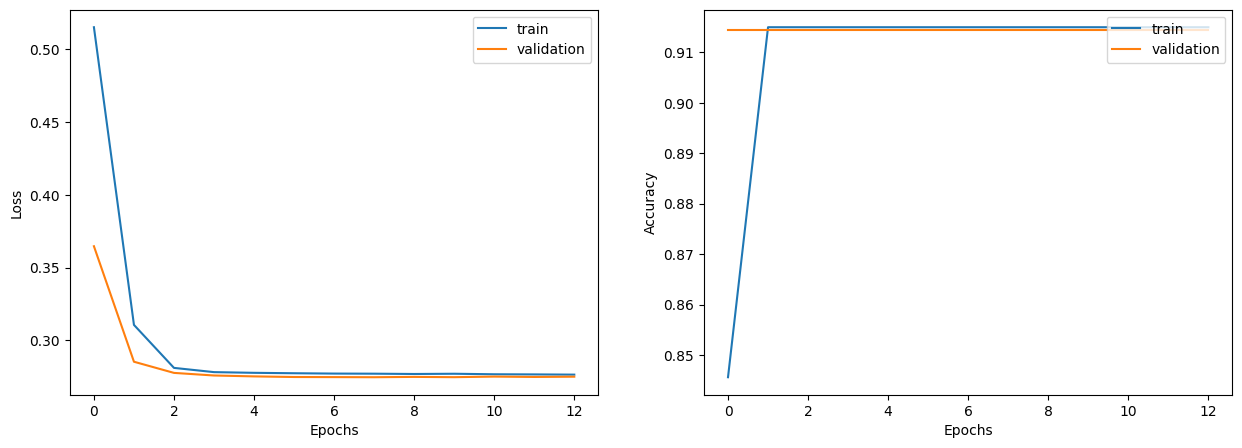

In [ ]:
display_learning_curves(history)

In [ ]:
node2vec_cc

,Node_id,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,...,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127,label
0,0,0.005144,0.000277,0.007812,0.007313,0.002355,-0.006308,-0.004954,-0.005947,-0.006130,...,-0.004378,-0.005743,-0.006740,0.003254,0.006872,0.006498,-0.000967,0.005113,0.001815,1
1,1,0.004769,0.007312,0.007773,-0.006644,-0.002392,-0.001578,0.000793,-0.004726,0.006117,...,0.004431,-0.002086,-0.001157,0.005833,-0.004358,-0.003364,0.000258,-0.002780,-0.002166,1
2,2,-0.002199,-0.007678,0.005631,0.007217,0.006261,0.005020,-0.001294,-0.002668,-0.004228,...,0.004649,0.001195,0.007447,-0.005784,-0.002033,0.001744,0.004287,-0.002659,-0.001851,1
3,3,0.001280,-0.007179,0.004191,0.000555,-0.003712,0.006510,0.004461,0.000978,-0.000633,...,0.003763,0.000784,-0.004057,0.003249,0.002570,0.006452,0.002042,-0.004020,0.007325,1
4,4,0.005147,-0.000680,0.000796,0.005810,-0.004373,0.001150,-0.005603,0.003892,0.002906,...,-0.004021,0.004444,0.002169,-0.006118,0.004841,-0.006888,-0.002582,-0.000259,0.007190,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2987,2987,-0.005089,-0.003899,-0.000417,-0.005175,-0.003333,-0.004904,0.007746,-0.005036,-0.005815,...,0.005927,-0.006374,-0.000438,0.006251,-0.001174,-0.007099,-0.006890,0.003828,0.002626,1
2988,2988,-0.002163,0.003639,-0.010361,0.005181,0.006588,-0.003225,-0.000208,0.000013,0.006767,...,-0.003134,0.000505,0.001895,0.003298,0.004574,-0.002961,-0.004885,0.011189,-0.009567,2
2989,2989,-0.005700,0.002228,-0.002893,-0.001707,0.002673,0.000121,0.007877,-0.004899,-0.001171,...,-0.001013,0.003436,-0.000466,0.002203,-0.007290,0.002979,-0.006950,0.005174,-0.003387,1
2990,2990,0.000921,0.006880,0.000592,-0.009694,0.003221,0.005006,-0.005299,-0.009057,0.007571,...,0.001858,0.006718,0.008395,-0.003167,0.004750,0.005460,0.005755,-0.000815,-0.004408,1


In [ ]:
import tensorflow as tf

def gcn_model_values(model, data):
    print('Extracting features based on GCN model........')
    with tf.device('/CPU:0'):
        pred = model.predict(data)
    return pred

gcn_train_data = gcn_model_values(gnn_model, x_train)
gcn_val_data = gcn_model_values(gnn_model, x_val)
gcn_test_data = gcn_model_values(gnn_model, x_test)

Extracting features based on GCN model........
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Extracting features based on GCN model........
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Extracting features based on GCN model........
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

model = LogisticRegression()

model.fit(gcn_train_data, y_train)

y_train_pred = model.predict(gcn_train_data)
y_test_pred = model.predict(gcn_test_data)
y_val_pred = model.predict(gcn_val_data)

Lr_test_accuracy = accuracy_score(y_test, y_test_pred)
Lr_val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Testing accuracy: {Lr_test_accuracy}")
print(f"Validation accuracy: {Lr_val_accuracy}")


Testing accuracy: 0.9055555555555556
Validation accuracy: 0.8717472118959108


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

max_depth = 10
min_samples_split = 5
model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split)

model.fit(gcn_train_data, y_train)

y_pred_val = model.predict(gcn_val_data)
Dt_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Dt_val_accuracy * 100))

y_pred_test = model.predict(gcn_test_data)
Dt_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Dt_test_accuracy * 100))


Validation accuracy: 83.09%
Testing accuracy: 86.11%


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(gcn_train_data, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

y_pred_val = best_model.predict(gcn_val_data)
Dt_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy (GridSearchCV): {:.2f}%".format(Dt_val_accuracy * 100))

y_pred_test = best_model.predict(gcn_test_data)
Dt_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy (GridSearchCV): {:.2f}%".format(Dt_test_accuracy * 100))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:  {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5}
Validation accuracy (GridSearchCV): 86.80%
Testing accuracy (GridSearchCV): 90.28%


In [ ]:
X_train = gcn_train_data
X_val = gcn_val_data
X_test = gcn_test_data

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_estimators = 100
max_depth = 10
min_samples_split = 5
model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split)

model.fit(gcn_train_data, y_train)

y_pred_val = model.predict(gcn_val_data)
Rf_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Rf_val_accuracy * 100))

y_pred_test = model.predict(gcn_test_data)
Rf_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Rf_test_accuracy * 100))


Validation accuracy: 86.99%
Testing accuracy: 90.28%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(gcn_train_data, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

y_pred_val = best_model.predict(gcn_val_data)
Rf_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy (GridSearchCV): {:.2f}%".format(Rf_val_accuracy * 100))

y_pred_test = best_model.predict(gcn_test_data)
Rf_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy (GridSearchCV): {:.2f}%".format(Rf_test_accuracy * 100))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 150}
Validation accuracy (GridSearchCV): 86.99%
Testing accuracy (GridSearchCV): 90.28%


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

C = 1.0
kernel = 'rbf'
gamma = 'scale'
model = SVC(C=C, kernel=kernel, gamma=gamma)

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)
Svm_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Svm_val_accuracy * 100))

y_pred_test = model.predict(X_test)
Svm_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Svm_test_accuracy * 100))


Validation accuracy: 87.17%
Testing accuracy: 90.56%


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

svm_model = SVC()

grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

y_pred_val = best_model.predict(X_val)
Svm_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy (GridSearchCV): {:.2f}%".format(Svm_val_accuracy * 100))

y_pred_test = best_model.predict(X_test)
Svm_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy (GridSearchCV): {:.2f}%".format(Svm_test_accuracy * 100))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Validation accuracy (GridSearchCV): 87.17%
Testing accuracy (GridSearchCV): 90.56%


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

n_estimators = 100
learning_rate = 1.0
algorithm = 'SAMME'
model = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate, algorithm=algorithm)

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)
Ada_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Ada_val_accuracy * 100))

y_pred_test = model.predict(X_test)
Ada_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Ada_test_accuracy * 100))


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Validation accuracy: 87.17%
Testing accuracy: 90.56%


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


n_estimators = 100
max_depth = None
min_samples_split = 2
random_state = 42
model = ExtraTreesClassifier(n_estimators=n_estimators, max_depth=max_depth,
                             min_samples_split=min_samples_split, random_state=random_state)

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)
Et_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Et_val_accuracy * 100))

y_pred_test = model.predict(X_test)
Et_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Et_test_accuracy * 100))


Validation accuracy: 86.62%
Testing accuracy: 89.44%


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}


et_model = ExtraTreesClassifier(random_state=42)

grid_search = GridSearchCV(estimator=et_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

y_pred_val = best_model.predict(X_val)
Et_val_accuracy = accuracy_score(y_val, y_pred_val)
Et_val_precision = precision_score(y_val, y_pred_val, average='weighted')
Et_val_recall = recall_score(y_val, y_pred_val, average='weighted')
Et_val_f1 = f1_score(y_val, y_pred_val, average='weighted')

print("Validation metrics (GridSearchCV):")
print("Accuracy: {:.2f}%".format(Et_val_accuracy * 100))
print("Precision: {:.2f}".format(Et_val_precision))
print("Recall: {:.2f}".format(Et_val_recall))
print("F1 Score: {:.2f}".format(Et_val_f1))

y_pred_test = best_model.predict(X_test)
Et_test_accuracy = accuracy_score(y_test, y_pred_test)
Et_test_precision = precision_score(y_test, y_pred_test, average='weighted')
Et_test_recall = recall_score(y_test, y_pred_test, average='weighted')
Et_test_f1 = f1_score(y_test, y_pred_test, average='weighted')

print("Testing metrics (GridSearchCV):")
print("Accuracy: {:.2f}%".format(Et_test_accuracy * 100))
print("Precision: {:.2f}".format(Et_test_precision))
print("Recall: {:.2f}".format(Et_test_recall))
print("F1 Score: {:.2f}".format(Et_test_f1))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Validation metrics (GridSearchCV):
Accuracy: 86.99%
Precision: 0.76
Recall: 0.87
F1 Score: 0.81
Testing metrics (GridSearchCV):
Accuracy: 90.28%
Precision: 0.82
Recall: 0.90
F1 Score: 0.86


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

alpha = 0.0001
max_iter = 1000
tol = 1e-3
model = SGDClassifier(alpha=alpha, max_iter=max_iter, tol=tol)

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)
Sgd_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Sgd_val_accuracy * 100))

y_pred_test = model.predict(X_test)
Sgd_test_accuracy = accuracy_score(y_test, y_pred_test)
Sgd_test_recall = recall_score(y_test, y_pred_test, average = 'macro')
Sgd_test_f1_score = f1_score(y_test, y_pred_test, average = 'macro')
print("Testing accuracy: {:.2f}%".format(Sgd_test_accuracy * 100))


Validation accuracy: 87.17%
Testing accuracy: 90.56%


#Scores

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression()

model.fit(gcn_train_data, y_train)

y_train_pred = model.predict(gcn_train_data)
y_test_pred = model.predict(gcn_test_data)
y_val_pred = model.predict(gcn_val_data)

Lr_test_accuracy = accuracy_score(y_test, y_test_pred)
Lr_val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Testing accuracy: {Lr_test_accuracy:.4f}")
print(f"Validation accuracy: {Lr_val_accuracy:.4f}")

for avg in ['macro', 'micro', 'weighted']:
    print(f"\n--- {avg.upper()} ---")
    print(f"Precision: {precision_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_test_pred, average=avg):.4f}")


Testing accuracy: 0.9056
Validation accuracy: 0.8717

--- MACRO ---
Precision: 0.3019
Recall:    0.3333
F1-score:  0.3168

--- MICRO ---
Precision: 0.9056
Recall:    0.9056
F1-score:  0.9056

--- WEIGHTED ---
Precision: 0.8200
Recall:    0.9056
F1-score:  0.8607


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(gcn_train_data, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

y_pred_val = best_model.predict(gcn_val_data)
Dt_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Dt_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

y_pred_test = best_model.predict(gcn_test_data)
Dt_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Dt_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")



Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:  {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5}

Validation accuracy: 0.8680

Validation (MACRO):
Precision: 0.2915
Recall:    0.3319
F1-score:  0.3104

Validation (MICRO):
Precision: 0.8680
Recall:    0.8680
F1-score:  0.8680

Validation (WEIGHTED):
Precision: 0.7624
Recall:    0.8680
F1-score:  0.8118

Testing accuracy: 0.9028

Testing (MACRO):
Precision: 0.4366
Recall:    0.3550
F1-score:  0.3579

Testing (MICRO):
Precision: 0.9028
Recall:    0.9028
F1-score:  0.9028

Testing (WEIGHTED):
Precision: 0.8539
Recall:    0.9028
F1-score:  0.8684


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

svm_model = SVC()

grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5,
                           scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

y_pred_val = best_model.predict(X_val)
Svm_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Svm_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

y_pred_test = best_model.predict(X_test)
Svm_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Svm_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")



Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Validation accuracy: 0.8717

Validation (MACRO):
Precision: 0.2906
Recall:    0.3333
F1-score:  0.3105

Validation (MICRO):
Precision: 0.8717
Recall:    0.8717
F1-score:  0.8717

Validation (WEIGHTED):
Precision: 0.7599
Recall:    0.8717
F1-score:  0.8120

Testing accuracy: 0.9056

Testing (MACRO):
Precision: 0.3019
Recall:    0.3333
F1-score:  0.3168

Testing (MICRO):
Precision: 0.9056
Recall:    0.9056
F1-score:  0.9056

Testing (WEIGHTED):
Precision: 0.8200
Recall:    0.9056
F1-score:  0.8607


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

et_model = ExtraTreesClassifier(random_state=42)

grid_search = GridSearchCV(estimator=et_model, param_grid=param_grid, cv=5,
                           scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} metrics (GridSearchCV):")
    print("Accuracy: {:.2f}%".format(accuracy_score(y_true, y_pred) * 100))

    # Weighted
    print("Precision (weighted): {:.4f}".format(precision_score(y_true, y_pred, average='weighted')))
    print("Recall (weighted): {:.4f}".format(recall_score(y_true, y_pred, average='weighted')))
    print("F1 Score (weighted): {:.4f}".format(f1_score(y_true, y_pred, average='weighted')))

    # Macro
    print("Precision (macro): {:.4f}".format(precision_score(y_true, y_pred, average='macro')))
    print("Recall (macro): {:.4f}".format(recall_score(y_true, y_pred, average='macro')))
    print("F1 Score (macro): {:.4f}".format(f1_score(y_true, y_pred, average='macro')))

    # Micro
    print("Precision (micro): {:.4f}".format(precision_score(y_true, y_pred, average='micro')))
    print("Recall (micro): {:.4f}".format(recall_score(y_true, y_pred, average='micro')))
    print("F1 Score (micro): {:.4f}".format(f1_score(y_true, y_pred, average='micro')))

evaluate_model("Validation", y_val, best_model.predict(X_val))

evaluate_model("Testing", y_test, best_model.predict(X_test))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Validation metrics (GridSearchCV):
Accuracy: 86.99%
Precision (weighted): 0.7597
Recall (weighted): 0.8699
F1 Score (weighted): 0.8111
Precision (macro): 0.2905
Recall (macro): 0.3326
F1 Score (macro): 0.3101
Precision (micro): 0.8699
Recall (micro): 0.8699
F1 Score (micro): 0.8699

Testing metrics (GridSearchCV):
Accuracy: 90.28%
Precision (weighted): 0.8198
Recall (weighted): 0.9028
F1 Score (weighted): 0.8593
Precision (macro): 0.3018
Recall (macro): 0.3323
F1 Score (macro): 0.3163
Precision (micro): 0.9028
Recall (micro): 0.9028
F1 Score (micro): 0.9028


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

n_estimators = 100
learning_rate = 1.0
algorithm = 'SAMME'
model = AdaBoostClassifier(n_estimators=n_estimators,
                           learning_rate=learning_rate,
                           algorithm=algorithm)

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)
Ada_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Ada_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

y_pred_test = model.predict(X_test)
Ada_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Ada_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



Validation accuracy: 0.8717

Validation (MACRO):
Precision: 0.2906
Recall:    0.3333
F1-score:  0.3105

Validation (MICRO):
Precision: 0.8717
Recall:    0.8717
F1-score:  0.8717

Validation (WEIGHTED):
Precision: 0.7599
Recall:    0.8717
F1-score:  0.8120

Testing accuracy: 0.9056

Testing (MACRO):
Precision: 0.3019
Recall:    0.3333
F1-score:  0.3168

Testing (MICRO):
Precision: 0.9056
Recall:    0.9056
F1-score:  0.9056

Testing (WEIGHTED):
Precision: 0.8200
Recall:    0.9056
F1-score:  0.8607


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

grid_search.fit(gcn_train_data, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

y_pred_val = best_model.predict(gcn_val_data)
Rf_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Rf_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

y_pred_test = best_model.predict(gcn_test_data)
Rf_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Rf_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 150}

Validation accuracy: 0.8699

Validation (MACRO):
Precision: 0.2905
Recall:    0.3326
F1-score:  0.3101

Validation (MICRO):
Precision: 0.8699
Recall:    0.8699
F1-score:  0.8699

Validation (WEIGHTED):
Precision: 0.7597
Recall:    0.8699
F1-score:  0.8111

Testing accuracy: 0.9028

Testing (MACRO):
Precision: 0.3018
Recall:    0.3323
F1-score:  0.3163

Testing (MICRO):
Precision: 0.9028
Recall:    0.9028
F1-score:  0.9028

Testing (WEIGHTED):
Precision: 0.8198
Recall:    0.9028
F1-score:  0.8593


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

alpha = 0.0001
max_iter = 1000
tol = 1e-3
model = SGDClassifier(alpha=alpha, max_iter=max_iter, tol=tol)

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)
Sgd_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Sgd_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

y_pred_test = model.predict(X_test)
Sgd_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Sgd_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")



Validation accuracy: 0.8717

Validation (MACRO):
Precision: 0.2906
Recall:    0.3333
F1-score:  0.3105

Validation (MICRO):
Precision: 0.8717
Recall:    0.8717
F1-score:  0.8717

Validation (WEIGHTED):
Precision: 0.7599
Recall:    0.8717
F1-score:  0.8120

Testing accuracy: 0.9056

Testing (MACRO):
Precision: 0.3019
Recall:    0.3333
F1-score:  0.3168

Testing (MICRO):
Precision: 0.9056
Recall:    0.9056
F1-score:  0.9056

Testing (WEIGHTED):
Precision: 0.8200
Recall:    0.9056
F1-score:  0.8607


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

lr_model = LogisticRegression(max_iter=1000)
sgd_model = SGDClassifier(max_iter=1100, tol=1e-3)

vc_model = VotingClassifier(
    estimators=[('lr', lr_model), ('sgd', sgd_model)],
    voting='hard'  # use 'hard' for majority voting
)

vc_model.fit(X_train, y_train)

y_pred_val = vc_model.predict(X_val)
vc_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {vc_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

y_pred_test = vc_model.predict(X_test)
vc_test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTesting accuracy: {vc_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_test_pred, average=avg):.4f}")


Validation accuracy: 0.8717

Validation (MACRO):
Precision: 0.2906
Recall:    0.3333
F1-score:  0.3105

Validation (MICRO):
Precision: 0.8717
Recall:    0.8717
F1-score:  0.8717

Validation (WEIGHTED):
Precision: 0.7599
Recall:    0.8717
F1-score:  0.8120

Testing accuracy: 0.9056

Testing (MACRO):
Precision: 0.3019
Recall:    0.3333
F1-score:  0.3168

Testing (MICRO):
Precision: 0.9056
Recall:    0.9056
F1-score:  0.9056

Testing (WEIGHTED):
Precision: 0.8200
Recall:    0.9056
F1-score:  0.8607


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(max_iter=1000, random_state=42)
sgd_model = SGDClassifier(loss="log_loss", max_iter=1200, random_state=42)  # supports predict_proba
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)
svc_model = SVC(probability=True, random_state=42)

stack_model = StackingClassifier(
    estimators=[
        ('lr', lr_model),
        ('sgd', sgd_model),
        ('rf', rf_model),
        ('gb', gb_model),
        ('svc', svc_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

y_pred_val = stack_model.predict(X_val)
val_acc = accuracy_score(y_val, y_pred_val)
print(f"\nValidation Accuracy: {val_acc:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

y_pred_test = stack_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
print(f"\nTesting Accuracy: {test_acc:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")



Validation Accuracy: 0.8717

Validation (MACRO):
Precision: 0.2906
Recall:    0.3333
F1-score:  0.3105

Validation (MICRO):
Precision: 0.8717
Recall:    0.8717
F1-score:  0.8717

Validation (WEIGHTED):
Precision: 0.7599
Recall:    0.8717
F1-score:  0.8120

Testing Accuracy: 0.9056

Testing (MACRO):
Precision: 0.3019
Recall:    0.3333
F1-score:  0.3168

Testing (MICRO):
Precision: 0.9056
Recall:    0.9056
F1-score:  0.9056

Testing (WEIGHTED):
Precision: 0.8200
Recall:    0.9056
F1-score:  0.8607


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m